In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
df = pd.read_csv('Admission_Predict_Ver1.1.csv')
X = df.drop('Chance of Admit ', axis=1).values
y = df['Chance of Admit '].values.reshape(-1, 1)
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [12]:
np.isnan(X).any()

False

In [7]:
#stocastic gradiant descent implementation
def stochastic_gradiant_descent(X, y, theta, learning_rate=0.01, n_epochs=50):
    m = len(X)
    for epoch in range(n_epochs):
        for i in range(m):
            random_index = np.random.randint(m)
            xi = X[random_index:random_index+1]
            yi = y[random_index:random_index+1]
            gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - learning_rate * gradients
    return theta


60
170
251
475
350
197
31
269
342
84
167
433
229
481
271
249
201
243
57
201
1
254
379
237
116
230
349
73
22
155
394
56
308
341
153
286
430
423
224
203
324
371
396
471
409
297
299
482
340
113
231
76
202
243
157
8
487
67
157
223
220
304
96
32
138
143
320
398
411
136
172
67
185
236
154
420
109
98
8
254
246
437
413
487
388
464
1
364
19
358
17
137
191
441
361
132
134
252
220
456
391
335
337
317
360
180
437
340
354
262
85
3
276
14
414
447
309
349
404
360
431
172
85
276
351
486
91
226
497
201
58
205
189
131
402
473
400
345
428
457
75
3
319
485
189
252
166
147
417
58
108
83
192
451
282
358
83
310
364
60
119
463
137
293
463
448
123
170
256
197
12
345
162
65
42
311
350
344
96
72
204
235
152
399
129
212
17
207
104
129
232
99
366
128
336
477
310
91
445
86
398
8
293
471
352
312
309
344
1
382
180
251
305
192
175
361
301
277
75
118
105
326
34
477
248
126
194
353
43
488
102
23
28
480
372
367
411
326
307
308
55
7
242
466
198
44
485
189
334
400
260
358
202
470
102
236
250
156
408
495
443
330
140
8
224
1

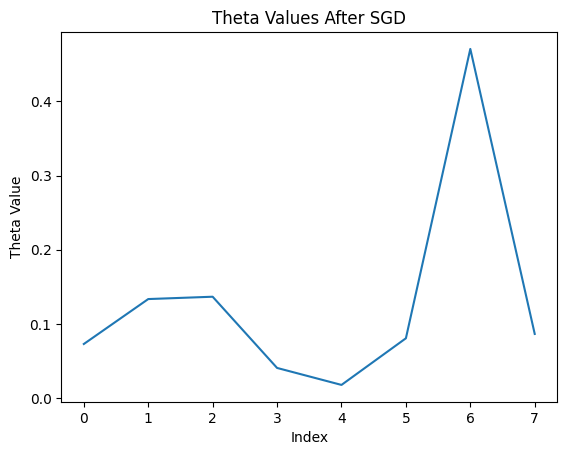

In [6]:
# Normalize X and y to prevent overflow
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)  # Standardize features
y = (y - np.mean(y)) / np.std(y)  # Standardize target values
y = y.reshape(-1, 1)  # Ensure y is a column vector

# Initialize theta
theta = np.random.randn(X.shape[1], 1)

# Use a smaller learning rate
learning_rate = 0.001

# Run stochastic gradient descent
theta = stochastic_gradiant_descent(X, y, theta, learning_rate=learning_rate)

# Plot the results
plt.plot(theta)
plt.title("Theta Values After SGD")
plt.xlabel("Index")
plt.ylabel("Theta Value")
plt.show()

In [47]:
# Print the final theta values
print("Final theta values:")
print(theta)

Final theta values:
[[0.05700171]
 [0.17283301]
 [0.14814584]
 [0.04362325]
 [0.01412703]
 [0.11369558]
 [0.47664269]
 [0.0866893 ]]


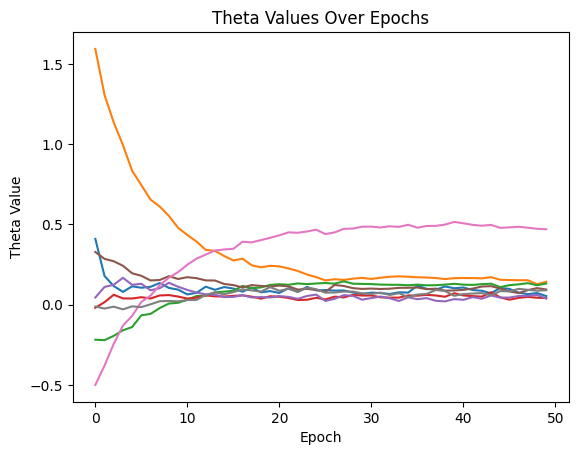

In [48]:
# plot graph to see how it is converging
theta_values = []
theta = np.random.randn(X.shape[1], 1)
for epoch in range(50):
    for i in range(len(X)):
        random_index = np.random.randint(len(X))
        xi = X[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        theta = theta - learning_rate * gradients
    theta_values.append(theta.copy())
theta_values = np.array(theta_values).squeeze()
plt.plot(theta_values)
plt.title("Theta Values Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Theta Value")
plt.show()

In [49]:
theta_values.shape

(50, 8)

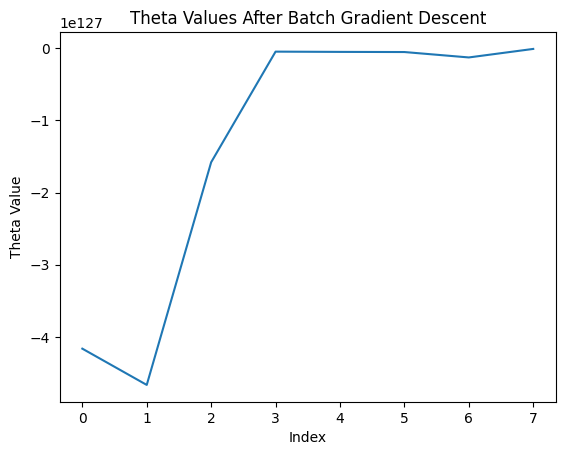

In [4]:
#batch gradient descent implementation
def batch_gradiant_descent(X, y, theta, learning_rate=0.01, n_epochs=50):
    m = len(X)
    for epoch in range(n_epochs):
        gradients = 2/m * X.T.dot(X.dot(theta) - y)
        theta = theta - learning_rate * gradients
    return theta

# Initialize theta
theta = np.random.randn(X.shape[1], 1)
# Use a smaller learning rate
learning_rate = 0.001
# Run batch gradient descent
theta = batch_gradiant_descent(X, y, theta, learning_rate = learning_rate)
# Plot the results
plt.plot(theta)
plt.title("Theta Values After Batch Gradient Descent")
plt.xlabel("Index")
plt.ylabel("Theta Value")
plt.show()

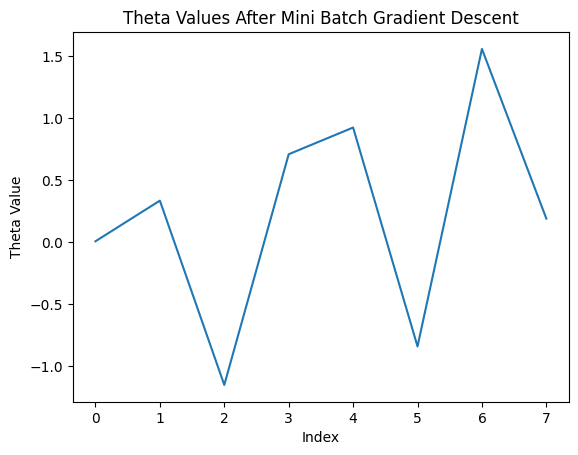

In [18]:
#mini batch gradient descent imlementation
def mini_batch_gradiant_descent(X, y, theta, learning_rate=0.01, n_epochs=50, batch_size=32):
    m = len(X)
    for epoch in range(n_epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            gradients = 2/len(X_batch) * X_batch.T.dot(X_batch.dot(theta) - y_batch)
            theta = theta - learning_rate * gradients
    return theta

# Initialize theta
theta = np.random.randn(X.shape[1], 1)
# Use a smaller learning rate
learning_rate = 0.000001
# Run mini batch gradient descent
theta = mini_batch_gradiant_descent(X, y ,theta, learning_rate=learning_rate, batch_size=128)
# Plot the results
plt.plot(theta)
plt.title("Theta Values After Mini Batch Gradient Descent")
plt.xlabel("Index")
plt.ylabel("Theta Value")
plt.show()